#  AR-MA · Laboratorio · La Ventosa, Oaxaca

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

Documento **autocontenido**: el Bloque 1 fija conceptos y el Bloque 2 ejecuta el
laboratorio completo (45 min).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

# Bloque 1 · Flujo de trabajo y conceptos clave

Antes de tocar datos, fijamos: (i) qué son los modelos AR/MA/ARMA y de dónde salen
$p$ y $q$, (ii) el ciclo Box-Jenkins, (iii) las cuatro herramientas estadísticas
que usaremos toda la sesión (ADF, ACF, PACF, Ljung-Box).

## ARMA en una línea — qué son $p$ y $q$

Trabajamos con tres modelos lineales sobre series **estacionarias**:

**AR(p) — autoregresivo de orden $p$.** El valor actual es combinación lineal de los
$p$ valores pasados *observados* más un choque blanco:

$$y_t \;=\; c + \phi_1\, y_{t-1} + \phi_2\, y_{t-2} + \cdots + \phi_p\, y_{t-p} + \varepsilon_t,
\qquad \varepsilon_t \sim \text{i.i.d.}\,\mathcal{N}(0, \sigma^2).$$

*Intuición física:* **inercia**. La serie recuerda sus propios valores recientes.

**MA(q) — media móvil de orden $q$.** El valor actual es combinación lineal de los
$q$ choques *pasados* más el choque actual:

$$y_t \;=\; \mu + \varepsilon_t + \theta_1\, \varepsilon_{t-1} + \theta_2\, \varepsilon_{t-2} + \cdots + \theta_q\, \varepsilon_{t-q}.$$

*Intuición física:* **eco de choques**. La serie reverbera durante $q$ pasos cada
perturbación, luego olvida.

**ARMA(p, q) — la combinación.** Inercia y eco a la vez:

$$y_t \;=\; c + \sum_{i=1}^{p} \phi_i\, y_{t-i} \;+\; \varepsilon_t + \sum_{j=1}^{q} \theta_j\, \varepsilon_{t-j}.$$

**De ahí salen $p$ y $q$:**

- $p$ = cuántos **rezagos del pasado observado** entran al modelo.
- $q$ = cuántos **rezagos de innovaciones** ($\varepsilon$) entran al modelo.
- Las $\varepsilon_t$ son **ruido blanco**: media cero, varianza constante, no correlacionadas.

Todo el trabajo del laboratorio es: dada una serie, **decidir $(p, q)$** y validar
que los residuales del modelo ajustado sean indistinguibles de ese ruido blanco.

## Qué es un "choque blanco" $\varepsilon_t$

Un **choque blanco** (o ruido blanco) es una secuencia de perturbaciones $\varepsilon_t$
con tres propiedades:

1. **Media cero:** $E[\varepsilon_t] = 0$. En promedio no empuja la serie hacia
   arriba ni hacia abajo.
2. **Varianza constante:** $\text{Var}(\varepsilon_t) = \sigma^2$ (homocedasticidad).
   Todos los choques tienen la misma "talla típica".
3. **Sin memoria:** $\text{Cov}(\varepsilon_t, \varepsilon_s) = 0$ si $t \neq s$.
   Saber el choque de ayer **no** dice nada del choque de hoy.

Es la versión matemática de **sorpresa pura**: información nueva, independiente,
sin estructura predecible.

### Ejemplos físicos — para el viento de La Ventosa

- Una **nube convectiva** pasa y reduce momentáneamente la insolación → cae el
  contraste térmico Golfo–Pacífico → el viento baja un escalón impredecible.
- Un **eddy turbulento** se desprende de un cerro cercano → ráfaga que no tiene
  memoria del minuto anterior.
- Una **perturbación sinóptica débil en altura** que el modelo de mesoescala no
  capturó y se siente como un pequeño "empujón" sobre la velocidad medida.
- **Error de medición** del anemómetro (cuantización, vibraciones del mástil).
  En la práctica este "choque" se mezcla con los anteriores y es indistinguible.

### Ejemplos en otros contextos — para ver que es universal

| Sistema                | Choque típico $\varepsilon_t$                                    |
|------------------------|------------------------------------------------------------------|
| Precio de una acción   | Tweet inesperado, decisión de la Fed, terremoto en Tokio         |
| Demanda eléctrica      | Partido de fútbol no programado, ola de calor súbita             |
| Tráfico vehicular      | Accidente puntual, semáforo que falla                            |
| Temperatura ambiente   | Apertura de una ventana, nube tapando el sol                     |
| Señal de radio         | Interferencia electromagnética aleatoria                         |
| Población de una especie | Brote epidémico, evento de mortalidad masiva, migración fortuita |

El patrón común: **eventos individualmente impredecibles, sin estructura temporal
entre ellos, que en conjunto generan la variabilidad "irreducible" del sistema**.

> **Lo que NO es ruido blanco.**
> - El **ciclo diario** del viento: es predecible (sale a la misma hora todos los días).
> - Una **racha multi-día** asociada a un frente frío: tiene memoria (hoy se parece a ayer).
> - **Tendencia** de calentamiento: empuja sistemáticamente en una dirección.
>
> Todo eso debe estar capturado por el modelo (climatología, AR, MA, tendencia
> explícita); lo que sobra son los $\varepsilon_t$.

### El choque en AR vs MA — mismo $\varepsilon_t$, distinto mecanismo de transmisión

El choque blanco es **matemáticamente el mismo** en ambos modelos. Lo que cambia es
cómo el sistema físico lo propaga en el tiempo.

**En AR — el choque se inyecta en el *estado*, que tiene inercia.**

El valor actual depende de los valores pasados *observables*. Cuando llega un choque,
modifica el estado, y de ahí la dinámica propia (los $\phi_i$) lo arrastra y lo olvida
geométricamente como $\phi^k$.

- *Analogía:* habitación climatizada. Abrir una ventana = $\varepsilon_t$. La
  temperatura no se recupera al instante porque la pared y el aire tienen capacidad
  térmica; el ajuste tiene escala de tiempo $\sim 1/(1-\phi)$.
- *La Ventosa:* una célula convectiva reduce el contraste térmico Golfo–Pacífico.
  El flujo sinóptico **no cambia abruptamente** porque tiene momentum atmosférico —
  baja un escalón y se recupera con la escala de tiempo del régimen.

**En MA — el choque tiene vida útil propia, el sistema no lo propaga.**

No hay estado interno que arrastre la perturbación; lo que persiste son los **choques
mismos** durante $q$ pasos y luego se acaban. Es la respuesta de un filtro de
impulso finito (FIR).

- *Analogía:* sala con reverberación de $q$ segundos. Un golpe se escucha durante
  $q$ pasos y desaparece sin dejar al sistema modificado.
- *La Ventosa:* los efectos MA suelen representar la **inercia del anemómetro** o el
  **suavizado del muestreo horario** (un evento sub-horario "ringa" en los datos sin
  alterar el flujo medio), eddies turbulentos de vida corta, o errores de proceso
  correlacionados (e.g., una nube mal interpolada por el reanálisis durante 2–3 h).

| Aspecto             | AR — choque vive en el **estado**          | MA — choque vive en **memoria de choques**  |
|---------------------|--------------------------------------------|---------------------------------------------|
| Mecanismo físico    | Sistema con inercia / capacitancia interna | Sin estado propio; eco finito               |
| Duración del efecto | Infinita pero decreciente como $\phi^k$    | **Exactamente $q$ pasos**                   |
| Ejemplo cotidiano   | Termostato, péndulo amortiguado, RLC       | Sala reverberante, filtro FIR digital       |
| En viento           | Inercia sinóptica del flujo                | Errores de medida, eddies cortos, suavizado |

> **Síntesis.** AR describe un sistema con **dinámica intrínseca** (ecuación
> diferencial / capacidad de almacenar energía). MA describe un sistema sin dinámica
> propia que **filtra ruido reciente**. ARMA admite que en la naturaleza casi nada
> es puro — coexisten inercia del sistema y eco de las perturbaciones recientes.

### Por qué importa para ARMA

ARMA modela **inercia** (AR) y **eco de choques** (MA), pero el motor que mueve
todo es la cadena $\{\varepsilon_t\}$. Si los choques tuvieran memoria (no fueran
blancos), quedaría estructura que el modelo no capturó.

Por eso el chequeo final de Box-Jenkins —**Ljung-Box sobre los residuales**— verifica
que los $\hat{\varepsilon}_t = y_t - \hat{y}_t$ se parezcan a ruido blanco. Son la
mejor evidencia empírica que tenemos sobre los $\varepsilon_t$ reales del sistema.

### De dónde sale cada cosa — no confundir orden con coeficientes

ACF y PACF eligen la **arquitectura** del modelo (cuántos parámetros); los valores
numéricos de $\phi_i, \theta_j$ los pone el optimizador después.

| Cosa               | De dónde sale                                                | Qué responde                  |
|--------------------|--------------------------------------------------------------|-------------------------------|
| $p,\, q$           | Inspección visual de **ACF/PACF** (dónde cortan o decaen)    | ¿Cuántos parámetros?          |
| $\phi_i,\, \theta_j$ | **Estimación por máxima verosimilitud** dentro de `ARIMA(...).fit()` | ¿Qué valor toma cada uno?     |
| $\varepsilon_t$    | **Residuales** del modelo ajustado: $\hat{\varepsilon}_t = y_t - \hat{y}_t$ | ¿Qué quedó sin explicar?      |

El flujo es: ACF/PACF → eliges $(p, q)$ → `ARIMA(serie, order=(p,0,q)).fit()` busca
los $\phi_i, \theta_j$ que maximizan la verosimilitud → calculas residuales →
Ljung-Box dictamina si son blancos.

> **Caso especial.** Para un AR(p) puro hay una igualdad exacta: $\text{PACF}(p) = \phi_p$
> (el último coeficiente). Por eso PACF "corta" justo en $p$. Pero $\phi_1, \dots, \phi_{p-1}$
> **no** son los valores de PACF en esos lags — son combinaciones no triviales que
> resuelve la estimación.

## El ciclo Box-Jenkins

Cuatro pasos, en loop:

1. **Identificar.** ¿La serie es estacionaria? ¿Qué orden $(p, q)$ probar?
   Herramientas: **ADF** + **ACF** + **PACF**.
2. **Estimar.** Ajustar `ARIMA(p, d, q)` por máxima verosimilitud.
3. **Diagnosticar.** ¿Los residuales son ruido blanco?
   Herramienta: ACF residual + **Ljung-Box**.
4. **Decidir.** Si los residuales NO son blancos → subir orden y volver a 2.
   Si lo son → parar y pronosticar.

> **Tip · cómo leer $(p, q)$ del par ACF/PACF.**
> - **PACF corta en lag $p$ y ACF decae** → empezar con **AR($p$)**.
> - **ACF corta en lag $q$ y PACF decae** → empezar con **MA($q$)**.
> - **Ambas decaen** → mezcla **ARMA**; típicamente $(p, q) = (1, 1)$ es buen primer disparo.
> - "Cortar" = el primer lag claramente dentro de la banda $\pm 1.96/\sqrt{n}$.
> - En la práctica, lee los **picos significativos** como cota superior del orden y
>   empieza **bajo** (humilde); subir es barato, sobreajustar duele en el diagnóstico.

> **Lección.** La identificación visual (ACF/PACF) da un *punto de partida*, no
> una respuesta única. La prueba final del modelo es Ljung-Box sobre los residuales.

## Raíz unitaria — el concepto que prueba el ADF

Considera un AR(1): $y_t = \phi\, y_{t-1} + \varepsilon_t$. El comportamiento depende
completamente del valor de $\phi$:

| $\phi$                 | Comportamiento                      | Nombre             |
|------------------------|-------------------------------------|--------------------|
| $\lvert\phi\rvert < 1$ | Estacionario, revierte a la media   | Estable            |
| $\phi = 1$             | Paseo aleatorio, sin reversión      | **Raíz unitaria**  |
| $\lvert\phi\rvert > 1$ | Explosivo, varianza diverge         | No estacionario    |

El nombre viene del **polinomio característico** del AR(p):
$1 - \phi_1 z - \cdots - \phi_p z^p = 0$. Si una raíz vale exactamente $z = 1$ →
"raíz unitaria".

**Fórmula general.** Para un AR(p), la condición de estacionariedad se lee del
polinomio característico:

$$\phi(z) \;=\; 1 - \phi_1\, z - \phi_2\, z^2 - \cdots - \phi_p\, z^p \;=\; 0.$$

- Todas las raíces $\lvert z_i \rvert > 1$ → **estacionario**.
- Alguna $\lvert z_i \rvert = 1$ → **raíz unitaria** (no estacionario).
- Alguna $\lvert z_i \rvert < 1$ → **explosivo**.

**Ejemplo con valores — AR(2) con raíz unitaria.** Considera

$$y_t \;=\; 1.5\, y_{t-1} \;-\; 0.5\, y_{t-2} \;+\; \varepsilon_t.$$

Aquí $\phi_1 = 1.5$ y $\phi_2 = -0.5$, así que el polinomio queda

$$1 - 1.5\, z + 0.5\, z^2 \;=\; 0.$$

**Despeje.** Factorizamos directamente (o aplicamos la fórmula cuadrática):

$$1 - 1.5\, z + 0.5\, z^2 \;=\; (1 - z)\,(1 - 0.5\, z).$$

Las raíces son entonces

$$z_1 = 1 \quad (\text{raíz unitaria}), \qquad z_2 = 2.$$

La presencia de $z_1 = 1$ confirma que el proceso **no es estacionario**. De hecho,
si tomamos la primera diferencia $\Delta y_t = y_t - y_{t-1}$, el resultado sí lo es:

$$\Delta y_t \;=\; 0.5\, \Delta y_{t-1} \;+\; \varepsilon_t,$$

un AR(1) estable (la otra raíz, $z_2 = 2$, sobrevive). El AR(2) original equivale a
un **ARIMA(1, 1, 0)** sobre la serie cruda — el "1" central es justamente el orden
de diferenciación necesario para eliminar la raíz unitaria.

> **Conexión con el ADF.** El ADF prueba exactamente esto: si el AR ajustado a tus
> datos tiene una raíz en $z = 1$. Cuando rechaza $H_0$, no hace falta diferenciar.
> Cuando no rechaza, conviene aplicar $\Delta$ y reintentar sobre la diferencia.

### Por qué $\phi = 1$ rompe todo

Si $y_t = y_{t-1} + \varepsilon_t$, resolviendo recursivamente desde $y_0$:

$$y_t = y_0 + \sum_{i=1}^{t} \varepsilon_i.$$

- **Varianza explota:** $\text{Var}(y_t) = t\sigma^2$ → crece linealmente.
- **Choques permanentes:** cada $\varepsilon_i$ se queda en el nivel para siempre
  (entra con coeficiente 1 en la suma).
- **No hay media a la cual revertir:** $E[y_t \mid y_0] = y_0$, depende de dónde arrancaste.

Si $|\phi| < 1$, en cambio, los choques decaen como $\phi^k$ → la serie *olvida* el
pasado y oscila alrededor de una media fija.

### Truco algebraico — lo que hace el ADF por dentro

Resta $y_{t-1}$ en ambos lados de $y_t = \phi\, y_{t-1} + \varepsilon_t$:

$$\Delta y_t = (\phi - 1)\, y_{t-1} + \varepsilon_t = \gamma\, y_{t-1} + \varepsilon_t,
\qquad \gamma \equiv \phi - 1.$$

Entonces:

- $\phi = 1 \iff \gamma = 0$ → **raíz unitaria**.
- $\phi < 1 \iff \gamma < 0$ → **estacionaria**.

El ADF estima $\gamma$ por MCO y prueba $H_0: \gamma = 0$. Por eso la hipótesis nula
es "hay raíz unitaria" — el caso $\gamma = 0$ es la frontera.

> **Ejemplos físicos.**
> - **Con raíz unitaria:** precio de una acción (cada noticia se incorpora al nivel
>   permanentemente), nivel del mar acumulado, posición de una partícula browniana.
> - **Sin raíz unitaria:** temperatura diaria de una ciudad (revierte a climatología),
>   velocidad del viento en escala sinóptica, oscilaciones cerca de un equilibrio.
>
> En La Ventosa esperamos **no raíz unitaria** — el viento no diverge, fluctúa en un
> rango acotado por la física. El ADF lo confirmará con $p \approx 0$.

## ADF — ¿la serie es estacionaria?

**Augmented Dickey-Fuller.** Versión aumentada del truco anterior: añade intercepto,
tendencia y $k$ rezagos de $\Delta y_t$ para manejar series reales. Se ajusta

$$\Delta y_t \;=\; \alpha + \beta\, t + \gamma\, y_{t-1} + \sum_{i=1}^{k} \delta_i\, \Delta y_{t-i} + \varepsilon_t,$$

y se contrasta el coeficiente $\gamma$ con el estadístico
$\hat{\gamma}/\text{SE}(\hat{\gamma})$ (distribución no-estándar, tabulada por
Dickey-Fuller — no es una $t$ de Student porque $y_{t-1}$ es no estacionaria bajo $H_0$).

- $H_0$: $\gamma = 0$ → la serie tiene **raíz unitaria** → **NO estacionaria** (paseo aleatorio).
- $H_1$: $\gamma < 0$ → la serie es **estacionaria**.
- Regla: $p < 0.05$ → rechazas $H_0$ → asumes estacionariedad.

El término *augmented* viene de los $k$ rezagos $\Delta y_{t-i}$, que absorben
autocorrelación residual; sin ellos sería el test de Dickey-Fuller original. La
opción `autolag="AIC"` que pasamos a `adfuller()` selecciona $k$ automáticamente.

**Cuidado.** ADF certifica una condición **necesaria pero no suficiente** para ARMA:
una serie con ciclo **estacional puro** puede pasar el ADF y aún violar los supuestos.

Por *estacional puro* entendemos una componente **periódica determinista** de
período fijo $s$ sobre ruido blanco — es decir, un patrón cíclico que **se repite
exactamente igual** cada $s$ pasos, ensuciado solo por choques independientes.
Forma general:

$$y_t \;=\; A\, \sin\!\left(\tfrac{2\pi t}{s}\right) + \varepsilon_t, \qquad \varepsilon_t \sim \text{ruido blanco}.$$

**Ejemplo concreto.** Temperatura horaria de una ciudad en una semana climática
estable, generada artificialmente como

$$T_t \;=\; 20 \;+\; 5\, \cos\!\left(\tfrac{2\pi\, t}{24}\right) \;+\; \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal{N}(0,\, 1^2).$$

- **Nivel medio:** $20\,°\text{C}$, constante en el tiempo.
- **Amplitud diaria:** $5\,°\text{C}$ (máximo al mediodía, mínimo a medianoche).
- **Período:** $s = 24$ h, exacto.
- **Ruido:** desviación típica $1\,°\text{C}$, independiente entre horas.

Si corres `adfuller(T)` sobre esta serie, el ADF rechaza $H_0$ con $p \approx 0$:
*"estacionaria"*. Y formalmente lo es: la media de largo plazo y la varianza son
constantes (no hay raíz unitaria, no hay tendencia).

**Pero** si ajustas un ARMA cualquiera a $T_t$ y miras la ACF de los residuales,
vas a ver **picos persistentes en lags 24, 48, 72, …** El motivo es estructural:

- Un coseno tiene autocorrelación que se **repite idéntica** cada $s$ lags, sin decaer.
- ARMA solo puede generar correlaciones que **decaen geométricamente**.
- Conclusión: ARMA no puede absorber un ciclo determinista; le queda estructura
  periódica íntegra en los residuales y Ljung-Box la detecta.

**Cómo se arregla.** Dos caminos:

- **Restar la estacionalidad determinista.** Estimas la "media por hora del día"
  (climatología horaria $\bar{T}(h)$) y modelas la anomalía $T_t - \bar{T}(h)$.
  *Esto es exactamente lo que haremos con el viento en P2.*
- **Usar SARIMA $(p,d,q)(P,D,Q)_{s}$.** El componente estacional con período
  $s = 24$ absorbe el ciclo dentro del modelo, sin necesidad de restar.

Por eso, antes de cualquier ARMA, siempre inspeccionamos ACF y climatología:
si vemos picos a múltiplos de $s$, sabemos que hay estacionalidad pendiente.

## ACF — autocorrelación

$\text{ACF}(k) = \text{corr}(y_t,\, y_{t-k})$. Correlación de la serie consigo misma
desfasada $k$ pasos. Mezcla efectos directos e indirectos (el lag 2 "ve" al lag 1).

- **AR(p):** ACF decae geométrica o sinusoidalmente — no corta abrupto.
- **MA(q):** ACF **corta** después del lag $q$.
- **Banda de confianza:** $\pm 1.96/\sqrt{n}$. Picos dentro de la banda son ruido.

## PACF — autocorrelación parcial

$\text{PACF}(k)$: correlación entre $y_t$ y $y_{t-k}$ **después de remover** el efecto
de los lags intermedios $y_{t-1}, \dots, y_{t-k+1}$. Aísla el efecto directo del lag $k$.

- **AR(p):** PACF **corta** después del lag $p$ → así identificamos $p$.
- **MA(q):** PACF decae geométricamente.

**Tabla mnemónica.**

| Modelo | ACF          | PACF         |
|--------|--------------|--------------|
| AR(p)  | decae        | corta en $p$ |
| MA(q)  | corta en $q$ | decae        |
| ARMA   | decae        | decae        |

## Ljung-Box — ¿los residuales son ruido blanco?

**Residual = lo que el modelo no explicó.** Una vez ajustado un ARMA, el modelo
produce un pronóstico un paso adelante $\hat{y}_t$ para cada instante. El **residual**
es la diferencia entre el dato real y ese pronóstico:

$$\hat{\varepsilon}_t \;=\; y_t \,-\, \hat{y}_t.$$

Son la estimación empírica de los choques blancos $\varepsilon_t$ del modelo. **Si el
modelo es adecuado**, los residuales deben verse como ruido blanco: media cero,
varianza constante, **sin autocorrelación**. Si todavía tienen estructura (picos en
ACF, correlación lag-a-lag, etc.) → el modelo dejó algo sobre la mesa y hay que
subir orden o cambiar de familia.

Ljung-Box es la **prueba formal de blancura** sobre esos residuales — combina muchos
lags en un solo $p$-value para no depender de inspección visual.

**Estadístico.** Prueba conjunta de autocorrelación sobre los primeros $h$ lags de
$\hat{\varepsilon}_t$:

$$Q_{LB}(h) = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n - k} \;\sim\; \chi^2_{h - p - q},$$

donde $\hat{\rho}_k$ es la autocorrelación muestral del residual al lag $k$ y los
grados de libertad descuentan los $p + q$ parámetros estimados (ajuste de Box-Pierce).

- $H_0$: las primeras $h$ autocorrelaciones son **todas cero** → residuales blancos.
- $H_1$: al menos una es distinta de cero → queda estructura sin modelar.
- Regla: $p > 0.05$ → **NO rechazas** → modelo adecuado.

**Por qué importa.** Si los residuales tienen autocorrelación, los intervalos de
confianza del pronóstico están **subestimados** — el modelo miente sobre su propia
incertidumbre. Es el chequeo no negociable de Box-Jenkins.

**Por qué miramos a 10 y 20 lags** (en datos horarios): 10 ≈ media jornada,
20 ≈ día completo. Si queda autocorrelación a esos horizontes, el pronóstico de
corto plazo será sesgado.

## AIC y BIC — comparar modelos cuando varios pasan el diagnóstico

Ljung-Box dice si un modelo es **adecuado** (residuales blancos: sí/no), pero a
menudo **varios** órdenes lo pasan. ¿Cuál eliges? Aquí entra el criterio
cuantitativo estándar: el **AIC** (Akaike Information Criterion).

$$\text{AIC} \;=\; -2\, \log L_{\max} \;+\; 2k,$$

donde $L_{\max}$ es la verosimilitud máxima del MLE y $k$ es el número de
parámetros estimados.

**Lectura: menor es mejor.**

- $-2\log L_{\max}$ → **premia el ajuste**: más verosimilitud → AIC más bajo.
- $+2k$ → **penaliza la complejidad**: cada parámetro extra cuesta 2 puntos de AIC.
- Un parámetro adicional solo "vale la pena" si reduce $-2\log L$ en **más de 2**.

**Reglas para compararlo:**

| Regla                            | Aclaración                                                       |
|----------------------------------|------------------------------------------------------------------|
| Valores absolutos: irrelevantes  | Solo comparas dos AIC entre **modelos sobre la misma serie**.    |
| $\Delta\text{AIC} > 2$           | Diferencia **significativa**.                                    |
| $\Delta\text{AIC} > 10$          | Diferencia **decisiva** — el modelo con menor AIC gana sin duda. |

**BIC (Bayesian Information Criterion)** es la prima conservadora:

$$\text{BIC} \;=\; -2\, \log L_{\max} \;+\; k\, \log n,$$

donde $n$ es el número de observaciones. Penaliza la complejidad más fuerte cuando
$n$ es grande ($\log n > 2$ apenas $n > 8$), así que tiende a **preferir modelos
más simples** que AIC. `statsmodels` imprime ambos en `summary()`.

> **Lectura combinada con Ljung-Box.** Ljung-Box dice *"¿este modelo es adecuado?"*
> (sí/no). AIC/BIC dicen *"entre los adecuados, ¿cuál es mejor?"* (ranking). Son
> complementarios: **nunca** elijas un modelo por AIC bajo si Ljung-Box rechaza —
> sería un ajuste vacío. Y si dos modelos pasan Ljung-Box con AIC parecido, gana
> el más simple (parsimonia).

En P4 vamos a ver esto en vivo: la columna AIC bajará de 3814 (AR(1)) → 3804 (AR(2))
→ 3769 (ARMA(2,1)), con saltos $> 10$ → mejoras decisivas en cada iteración.

## Helpers — los dos pasos del ciclo, codificados

- `mirar()`: identificación (ADF + ACF + PACF).
- `diagnostico()`: validación (residuales + ACF residual + Ljung-Box).

In [2]:
def mirar(serie, nombre, lags=30):
    """Identificación: serie temporal + ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplot_mosaic(
        [["serie", "serie"],
         ["acf",   "pacf"]],
        figsize=(12, 6),
    )
    serie.plot(ax=axes["serie"], lw=0.5, color="C0")
    axes["serie"].axhline(serie.mean(), color="k", lw=0.5, alpha=0.5)
    axes["serie"].set_title(f"Serie — {nombre}")
    plot_acf(serie,  lags=lags, ax=axes["acf"]);  axes["acf"].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes["pacf"], method="ywm")
    axes["pacf"].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico(modelo, nombre, lags=20):
    """Validación: residuales + ACF residual + PACF residual + Ljung-Box."""
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid,  lags=lags, ax=axes[1]); axes[1].set_title("ACF de residuales")
    plot_pacf(resid, lags=lags, ax=axes[2], method="ywm")
    axes[2].set_title("PACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

# Bloque 2 · Laboratorio (45 min)

## P1 · Los datos · La Ventosa, Oaxaca · 5 min

- **Sitio:** 16.55°N, 94.78°W. Corredor eólico del Istmo de Tehuantepec, uno de los
  mayores recursos eólicos del continente. Vientos térmicos por contraste de presión
  entre el Golfo de México y el Pacífico, canalizados por el istmo.
- **Periodo:** jun–ago 2023, resolución horaria.
- **Variable:** velocidad del viento a 10 m.
- **Fuente:** ERA5 (reanálisis ECMWF) vía Open-Meteo.

**Por qué este dataset para enseñar ARMA:**
- ~2200 obs → potencia estadística suficiente.
- Ciclo diario explícito → enseña por qué hay que desestacionalizar antes.
- Persistencia no trivial → forzará iterar Box-Jenkins (no se cierra al primer intento).
- Relevante para el alumno (energía eólica).

2208 obs horarias · 2023-06-01 00:00:00 a 2023-08-31 23:00:00
media = 4.14 m/s
desv  = 2.37 m/s
máx   = 9.36 m/s


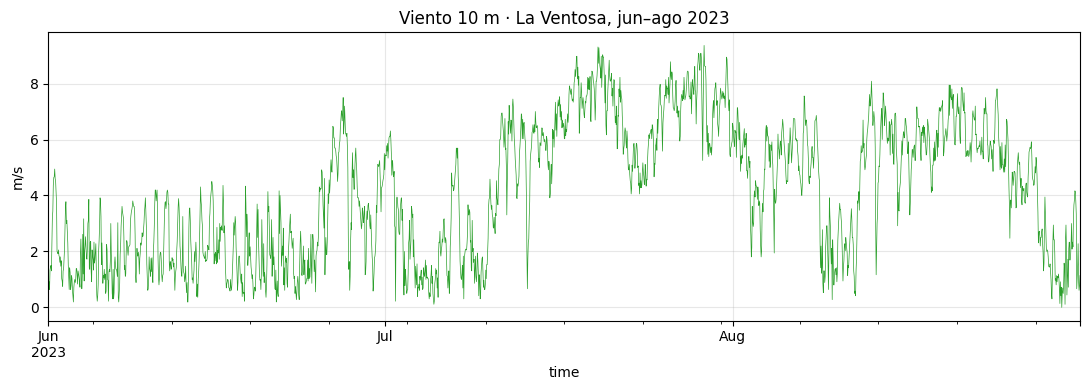

In [3]:
viento = pd.read_csv("../data/viento_la_ventosa_2023.csv",
                     skiprows=3, parse_dates=["time"],
                     index_col="time")
viento.columns = ["ws_kmh"]
viento["ws"] = viento["ws_kmh"] / 3.6  # km/h → m/s
viento = viento["ws"]

print(f"{len(viento)} obs horarias · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.2f} m/s")
print(f"desv  = {viento.std():.2f} m/s")
print(f"máx   = {viento.max():.2f} m/s")

viento.plot(lw=0.5, color="C2", title="Viento 10 m · La Ventosa, jun–ago 2023")
plt.ylabel("m/s"); plt.tight_layout(); plt.show()

**Lectura a ojo.** Hay rachas multi-día (escala sinóptica) y un latido de alta
frecuencia que sugiere ciclo diario. Antes de tocar ARMA hay que verificar dos cosas:
(1) estacionariedad y (2) ausencia de estacionalidad determinista que se vaya a colar
a los residuales.

> **Para discutir con la clase.**
> - ¿Qué **otras variables físicas** querrían medir para mejorar el pronóstico?
>   (Presión, temperatura, gradiente térmico Golfo-Pacífico, índices climáticos como ENSO).
>   Anticipa el puente a SARIMAX/exógenas.
> - ¿Por qué viento a 10 m y no a altura de buje (~80 m)? (10 m es lo que da ERA5
>   con calidad estándar; para producción real se extrapola con perfil logarítmico
>   o se usan productos a 100 m. Con esta serie aprendemos *método*, no *operación*).
> - ¿Qué tan representativo es jun–ago de todo el año? (Mala. Es temporada de máximos
>   en La Ventosa — invierno tiene un régimen distinto. Lo veremos como ejercicio).

## P2 · ¿Podemos usar AR-MA aquí? · 10 min

In [4]:
stat, p, *_ = adfuller(viento, autolag="AIC")
print(f"ADF sobre serie cruda:  p = {p:.4f}  →  "
      f"{'estacionaria' if p < 0.05 else 'NO estacionaria'}")

ADF sobre serie cruda:  p = 0.0668  →  NO estacionaria


**¿Y si el ADF dice "NO estacionaria"?** Es lo más probable en estos datos — y la
razón **no es** que el viento tenga raíz unitaria. ADF solo prueba un mecanismo
específico (paseo aleatorio), y cuando hay otra fuente fuerte de persistencia el
test puede confundirse. Tres causas posibles para un "NO estacionaria":

1. **Raíz unitaria genuina:** el proceso es realmente un paseo aleatorio.
2. **Tendencia determinista:** la serie sube/baja sistemáticamente.
3. **Estacionalidad determinista fuerte:** un ciclo periódico que crea persistencia
   aparente entre observaciones y empuja al test hacia el rechazo de estacionariedad.

Para el viento horario jun–ago, **la causa #3 es la dominante**: el ciclo diario
satura la correlación temporal y el ADF, que no tiene mecanismo para descomponer la
señal, lo lee como falta de estacionariedad.

Si el ADF hubiera dicho "estacionaria", el problema sería **simétrico**: nos habría
dado falsa tranquilidad, ocultando el mismo ciclo diario que ARMA no puede modelar.

**Conclusión, sea cual sea el veredicto del ADF:** hay que diagnosticar visualmente.
Verifiquemos el ciclo diario explícitamente con ACF/PACF y climatología.

> **Error común que aquí se vuelve operativo.** Hay dos versiones simétricas, según
> qué diga el ADF:
>
> - **"ADF dice estacionaria → puedo ajustar ARMA."** Falso si hay estacionalidad
>   determinista: el ciclo se filtrará íntegro a los residuales.
> - **"ADF dice NO estacionaria → debo diferenciar (ARIMA con $d \geq 1$)."** Falso
>   si la causa es estacionalidad: diferenciar **no cura ciclos deterministas**, solo
>   raíces unitarias. Acabarías con un modelo sobre-integrado y el ciclo intacto.
>
> ADF certifica/refuta una propiedad necesaria, pero **no suficiente** ni
> **específica**. La prueba final del modelo no es ADF sobre los datos — es
> Ljung-Box sobre los residuales.

### Confirmación visual — ACF y PACF de la serie cruda

ACF/PACF son la **otra ruta** (además de la climatología) para detectar estacionalidad:
si hay un ciclo de período $s$, aparecen picos en lags $s, 2s, 3s, \dots$

ADF · viento crudo:  estadístico = -2.743,  p = 0.0668  →  NO estacionaria


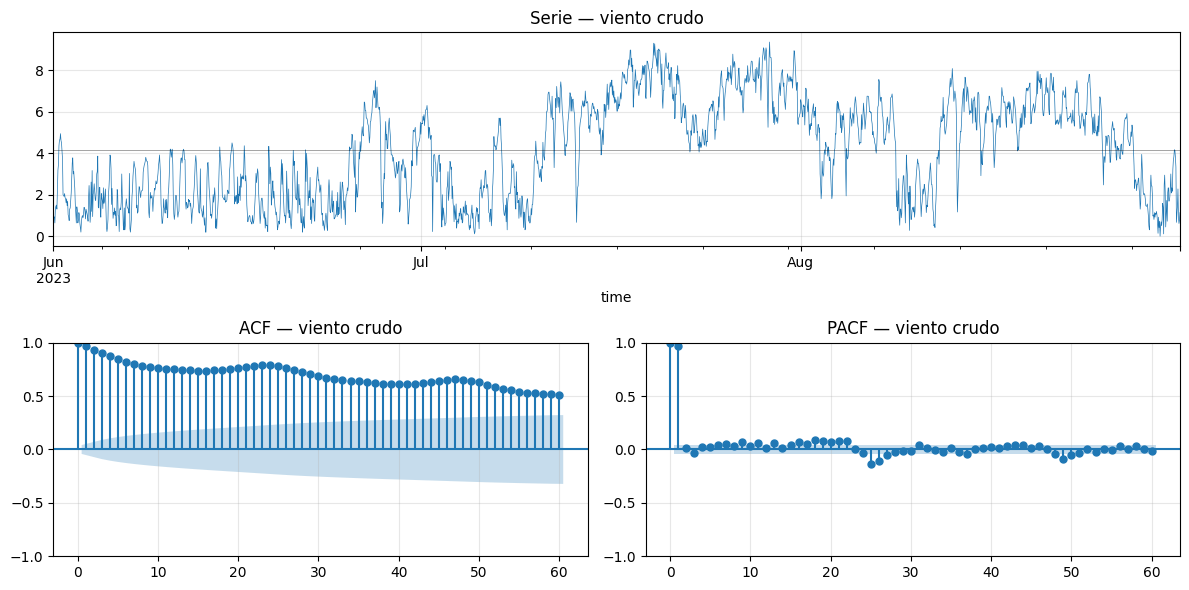

In [5]:
mirar(viento, "viento crudo", lags=60)

**Lectura.** Independientemente del veredicto del ADF, la **ACF muestra picos claros
en lags 24 y 48** — la firma inequívoca del ciclo diario. PACF tiene además un
patrón complejo que mezcla la persistencia sinóptica con la estacionalidad.

Esto **explica** lo que vio el ADF: la correlación tan fuerte a múltiplos de 24 h
es la que satura el test y le impide separar señal periódica de raíz unitaria.

Tenemos así **tres ángulos independientes** sobre el mismo problema:

- **Formal (ADF):** ambiguo — solo prueba raíz unitaria, no separa estacionalidad.
- **Visual (ACF/PACF):** picos en múltiplos de 24 h → estacionalidad pendiente.
- **Físico (climatología, siguiente celda):** el viento sube por la tarde, baja por
  la noche — patrón térmico diario.

Los tres apuntan a lo mismo: hay que restar la estacionalidad antes de ajustar ARMA.

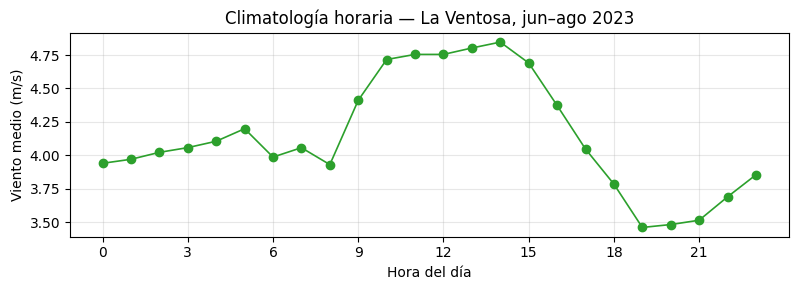

Rango climatológico: 3.46 a 4.85 m/s
Amplitud diaria:     1.39 m/s


In [6]:
clima_h = viento.groupby(viento.index.hour).mean()

fig, ax = plt.subplots(figsize=(8, 3))
clima_h.plot(ax=ax, marker="o", lw=1.2, color="C2")
ax.set_xlabel("Hora del día"); ax.set_ylabel("Viento medio (m/s)")
ax.set_title("Climatología horaria — La Ventosa, jun–ago 2023")
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

print(f"Rango climatológico: {clima_h.min():.2f} a {clima_h.max():.2f} m/s")
print(f"Amplitud diaria:     {clima_h.max() - clima_h.min():.2f} m/s")

Hay un ciclo diario marcado — el contraste térmico levanta el viento por la tarde.
Esa estructura es **determinista**: no la modelamos con ARMA, la **restamos** y
trabajamos sobre la anomalía. Lo que quede es lo que ARMA puede aspirar a explicar.

> **Para discutir con la clase (decisión de diseño).**
> - **Opción A:** restar climatología y modelar la anomalía con ARMA (lo que haremos).
> - **Opción B:** dejar la serie cruda y modelar todo con SARIMA $(p,d,q)(P,D,Q)_{24}$.
>
> ¿Trade-offs?
> - A es más interpretable (la climatología tiene significado físico explícito) y
>   permite separar "patrón conocido" de "dinámica residual".
> - B es más automático y maneja mejor cambios de fase del ciclo a lo largo del año.
> - En producción operativa de viento, lo más frecuente es **A**: pronostican la
>   anomalía y suman la climatología (a veces con una climatología más fina que
>   "media por hora", como una climatología por mes y hora).

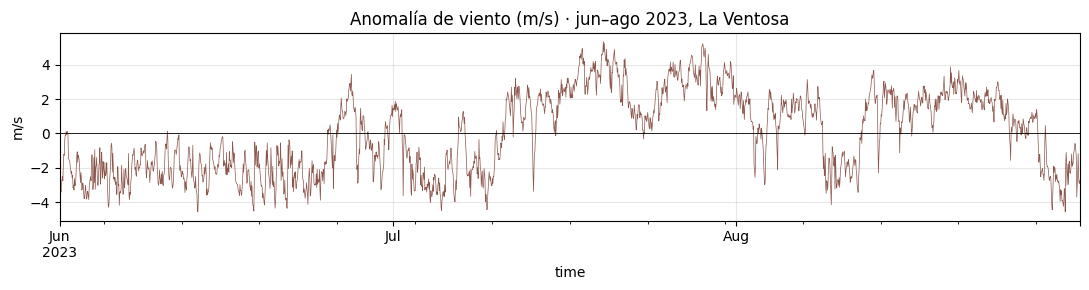

In [7]:
ws_anom = viento - viento.index.hour.map(clima_h)

fig, ax = plt.subplots(figsize=(11, 3))
ws_anom.plot(ax=ax, lw=0.5, color="C5")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Anomalía de viento (m/s) · jun–ago 2023, La Ventosa")
ax.set_ylabel("m/s")
plt.tight_layout(); plt.show()

La anomalía oscila alrededor de cero, sin patrón obvio a ojo. **Ahí vive la dinámica
estocástica que ARMA puede modelar.** Cumplimos los supuestos:

- Estacionariedad ✓
- Sin estacionalidad determinista pendiente ✓

> **Lección.** ARMA modela la dinámica estocástica que queda **después** de quitar
> lo determinista (tendencia, estacionalidad). No es magia: si le metes ciclo diario,
> te lo devolverá íntegro en los residuales.

## P3 · Identificación · 5 min

ADF · anomalía viento:  estadístico = -2.662,  p = 0.0809  →  NO estacionaria


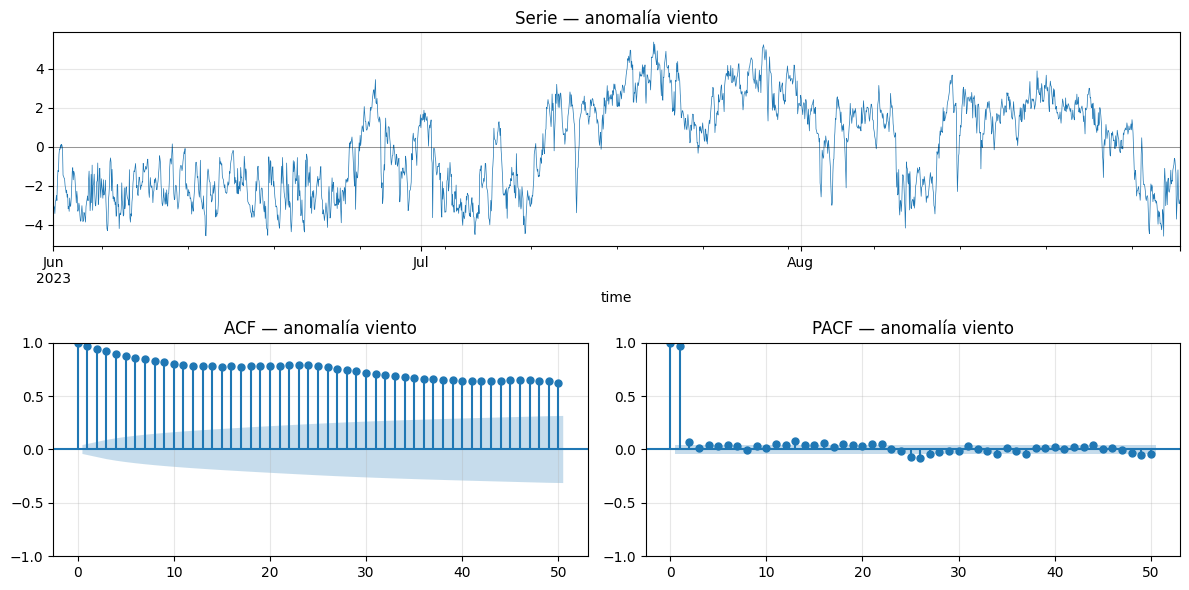

In [8]:
mirar(ws_anom, "anomalía viento", lags=50)

**Lectura.**

- **ADF:** $p \approx 0.08$ — **borderline, no rechaza** $H_0$ al 5%. La anomalía
  sigue mostrando persistencia muy alta. No es raíz unitaria pura (la serie no
  diverge y los picos del ciclo desaparecieron), pero el ADF está casi al límite.
  Veremos en P4 que esto se refleja en un $\phi$ del AR(1) muy cerca de 1.
- **ACF:** decae **lentamente** — la memoria va mucho más allá de unos pocos lags,
  consistente con la persistencia alta que sospecha el ADF.
- **PACF:** picos claros en lag 1 (y un eco en lag 2); después dentro de banda.

**Hipótesis de orden:** AR(1) o AR(2). Empezamos humildes con **AR(1)** y subimos
si los diagnósticos lo piden. Box-Jenkins no premia adivinar, premia **iterar con criterio**.

> **Pausa pedagógica (90 s).** Antes de correr la siguiente celda, pedir a los alumnos
> que **propongan un orden $(p, q)$** mirando ACF y PACF. Recoger 3-4 propuestas en el
> pizarrón. Casi seguro habrá un mix de AR(2), AR(3), ARMA(1,1) y ARMA(2,1). Esa
> diversidad es exactamente la realidad: identificación visual da *un punto de partida*,
> no una respuesta única.

## P4 · Iteración Box-Jenkins · 15 min

Tres ajustes con la misma rutina: **estimar → diagnosticar → decidir**.

### Iteración 1 · AR(1)

phi = 0.970    AIC = 3814.2


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


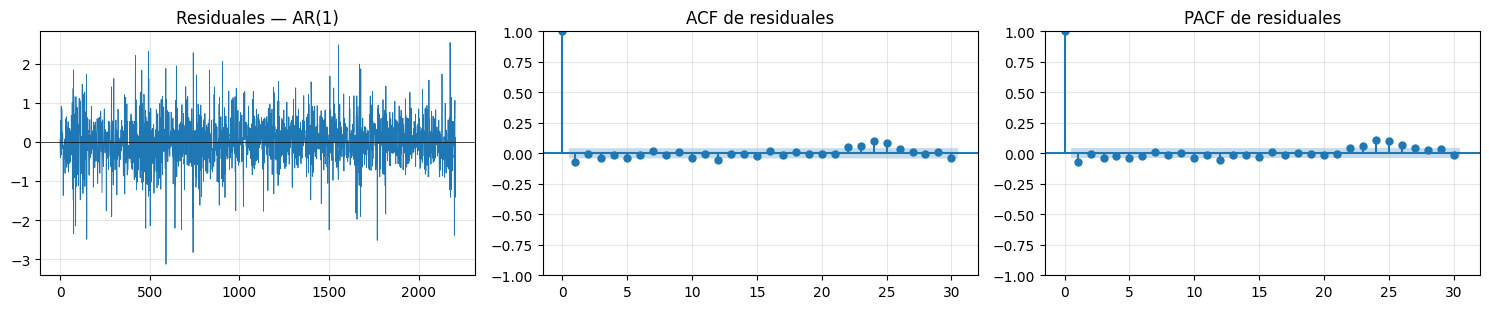

Ljung-Box · AR(1)
    lb_stat  lb_pvalue
10  22.7234     0.0118
20  32.3597     0.0396


,lb_stat,lb_pvalue
10,22.723397,0.011815
20,32.359656,0.039614


In [9]:
ar1_w = ARIMA(ws_anom, order=(1, 0, 0)).fit()
print(f"phi = {ar1_w.params['ar.L1']:.3f}    AIC = {ar1_w.aic:.1f}")
diagnostico(ar1_w, "AR(1)", lags=30)

**Veredicto AR(1).** $\phi \approx 0.97$, AIC $\approx 3814$. Ljung-Box rechaza
($p \approx 0.01$ a 10 lags, $p \approx 0.04$ a 20) → los residuales **no** son
ruido blanco. La ACF/PACF residuales aún muestran picos pequeños en los primeros
lags. AR(1) capturó la persistencia más obvia pero dejó estructura sin modelar.

**Decisión:** subir orden.

> **Para discutir con la clase.**
> - $\phi \approx 0.97$ — **muy alto, casi en el umbral de raíz unitaria**. Vida media =
>   $-\ln 2 / \ln(0.97) \approx 23$ horas: una desviación tarda casi un día completo en
>   reducirse a la mitad. Es persistencia mayor que la sinóptica pura (frentes de 2–5
>   días) — probablemente combina **memoria sinóptica** con **restos del ciclo diario**
>   que la climatología por hora no removió día a día.
> - Esto encaja con el ADF borderline sobre la anomalía: con $\phi$ tan cerca de 1, la
>   serie está al borde del paseo aleatorio y al ADF le cuesta separar.
> - Si paráramos aquí y usáramos este AR(1) en producción, ¿qué se rompería?
>   (Subestimaríamos la incertidumbre — los IC del pronóstico serían demasiado estrechos
>   porque asumen residuales blancos; con residuales correlacionados, los errores reales
>   son más grandes que los teóricos).

### Iteración 2 · AR(2)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0943      0.441     -0.214      0.831      -0.958       0.769
ar.L1          0.8969      0.016     56.605      0.000       0.866       0.928
ar.L2          0.0752      0.015      4.986      0.000       0.046       0.105
sigma2         0.3262      0.007     47.793      0.000       0.313       0.340

AIC = 3803.7  (AR(1) tenía 3814.2)


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


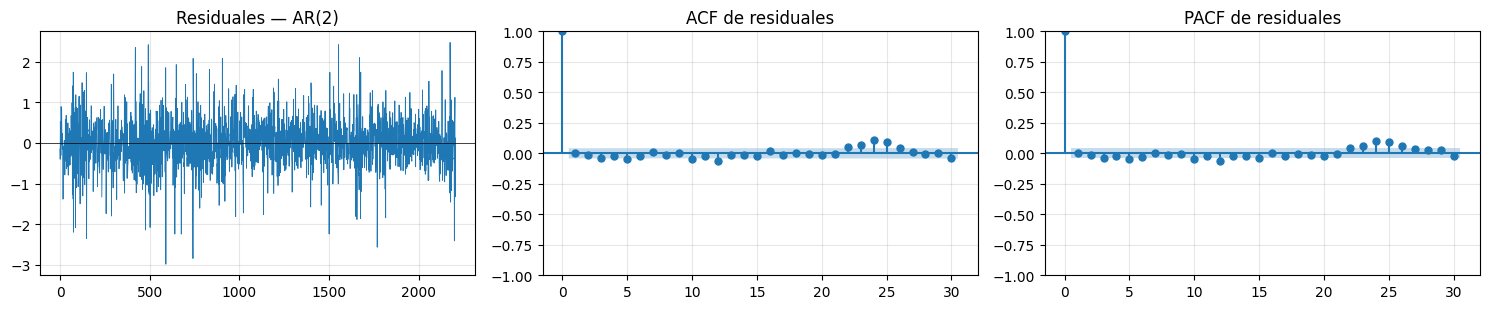

Ljung-Box · AR(2)
    lb_stat  lb_pvalue
10  15.4368     0.1169
20  27.7842     0.1146


,lb_stat,lb_pvalue
10,15.436801,0.116930
20,27.784229,0.114606


In [10]:
ar2_w = ARIMA(ws_anom, order=(2, 0, 0)).fit()
print(ar2_w.summary().tables[1])
print(f"\nAIC = {ar2_w.aic:.1f}  (AR(1) tenía {ar1_w.aic:.1f})")
diagnostico(ar2_w, "AR(2)", lags=30)

**Veredicto AR(2).** $\phi_1 \approx 0.90$, $\phi_2 \approx 0.075$, AIC $\approx 3804$
(bajó ~10 unidades respecto a AR(1)). Ambos coeficientes son significativos ($z = 57$
y $z = 5$). Ljung-Box **ya no rechaza**: $p \approx 0.12$ a 10 y 20 lags. ACF/PACF
residuales se ven prácticamente dentro de banda.

Técnicamente AR(2) ya es **adecuado** (LB no rechaza). Pero los $p$-values quedan
cerca del umbral del 5% — hay holgura mejorable.

**Decisión:** probar **ARMA(2,1)** — añadir un término MA suele bajar más el AIC y
alejar el $p$-value del borde sin escalar mucho el orden AR. Es la jugada típica en
Box-Jenkins cuando un AR(p) "alcanza pero apenas".

> **Para discutir con la clase.**
> - ¿Por qué probamos ARMA(2,1) y no AR(3)? (Empíricamente, en muchas series un MA(1)
>   captura "el último eco" más eficientemente que un AR adicional. ARMA(2,1) tiene 3
>   parámetros como AR(3), pero es más flexible. Si ARMA(2,1) no funcionara, AR(3)
>   sería la siguiente prueba).
> - ¿Cómo sabemos que no estamos sobreajustando con ARMA(2,1)? (Tres pistas: AIC sigue
>   bajando, los tres coeficientes son significativos, y los residuales se vuelven más
>   blancos. Si alguno de esos tres fallara, sería señal de sobreajuste).

### Iteración 3 · ARMA(2, 1)

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3471      0.843     -0.412      0.681      -2.000       1.305
ar.L1          1.8332      0.024     76.881      0.000       1.786       1.880
ar.L2         -0.8340      0.023    -35.512      0.000      -0.880      -0.788
ma.L1         -0.9378      0.017    -55.002      0.000      -0.971      -0.904
sigma2         0.3209      0.007     47.696      0.000       0.308       0.334

AIC = 3769.2


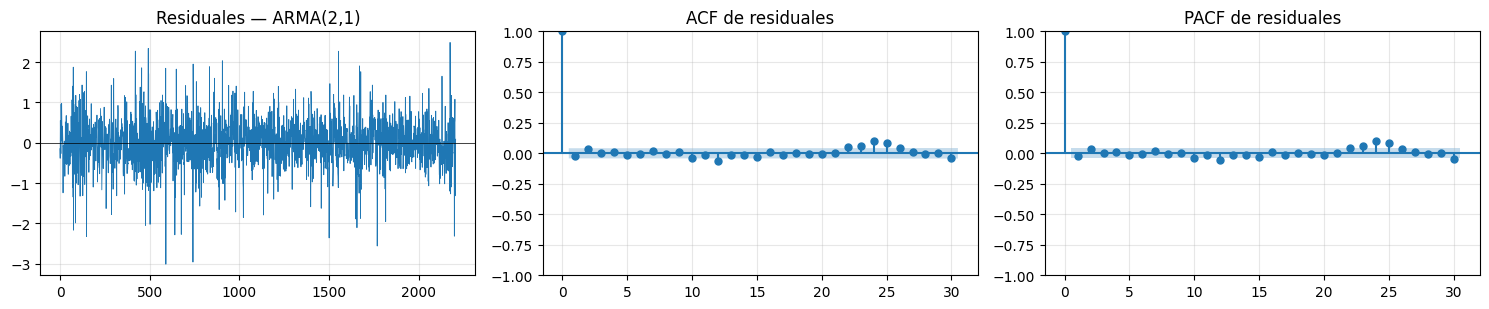

Ljung-Box · ARMA(2,1)
    lb_stat  lb_pvalue
10   9.7992     0.4583
20  22.2304     0.3281


,lb_stat,lb_pvalue
10,9.799193,0.458284
20,22.230393,0.328141


In [11]:
arma21_w = ARIMA(ws_anom, order=(2, 0, 1)).fit()
print(arma21_w.summary().tables[1])
print(f"\nAIC = {arma21_w.aic:.1f}")
diagnostico(arma21_w, "ARMA(2,1)", lags=30)

**Veredicto ARMA(2,1).** $\phi_1 \approx 1.83$, $\phi_2 \approx -0.83$,
$\theta_1 \approx -0.94$, AIC $\approx 3769$ (cae ~35 unidades más). Los tres
coeficientes son altamente significativos ($|z| > 35$ todos). Ljung-Box **claramente
no rechaza**: $p \approx 0.46$ a 10 lags y $p \approx 0.33$ a 20. Los residuales son
indistinguibles de ruido blanco. **Aquí paramos** — subir más orden no aportaría.

> **Nota técnica.** Los coeficientes AR del ARMA(2,1) son grandes en magnitud y las
> raíces del polinomio característico $1 - 1.83\, z + 0.83\, z^2 = 0$ están cerca de
> la frontera de estacionariedad ($|z| \approx 1.0$ y $|z| \approx 1.2$). Esto es
> consistente con que la anomalía tiene persistencia muy alta (casi raíz unitaria,
> como anticipó el ADF). El término $\theta_1 \approx -0.94$ cancela parcialmente
> esa persistencia y produce residuales blancos. Para producción seria, valdría
> comparar contra ARIMA(0,1,1) o ARIMA(1,1,1) — pero para los fines de este lab,
> ARMA(2,1) basta.

### Lectura visual fina — ¿en qué fijarte al mirar las tres figuras?

Ya ajustaste AR(1), AR(2) y ARMA(2,1) y tienes las tres figuras de diagnóstico
(residuales + ACF + PACF) sobre la pantalla. Antes de pasar al resumen numérico,
vale la pena entrenar el ojo en lo que están contando:

**1. Los residuales temporales (panel izquierdo de cada fila).**

- Deben verse como una "nube" centrada en cero, sin trama visible — ni rachas,
  ni cambios sistemáticos de varianza, ni saltos.
- AR(1) deja una serie ligeramente más estructurada (oscilaciones suaves); AR(2)
  y ARMA(2,1) se ven más "ruidosas" en el sentido bueno — más parecidas a ruido
  blanco a simple vista.

**2. ACF residual (panel central).**

- **Lag 1 al 5:** estos son los que más importa cerrar (corto plazo). AR(1) deja
  un pequeño negativo en lag 1; AR(2) y ARMA(2,1) lo limpian.
- **Lag 22–26:** ⚠️ **fíjate con cuidado aquí**. Aparece en los **tres modelos**
  un cúmulo pequeño de picos justo cerca de lag 24, que sobrevive incluso al
  ARMA(2,1). Magnitud individual ~0.05–0.07, en el límite de la banda $\pm 0.04$.
- **Lags grandes (> 26):** dentro de banda, ruido normal.

**3. PACF residual (panel derecho).** Mismo patrón que ACF — banda limpia salvo
el cúmulo cerca de lag 24.

**¿Qué significa el cúmulo persistente en lag 24?** Es la firma del **ciclo
diario residual** que la climatología por hora **no removió por completo**: el
ciclo varía día a día (amplitud distinta, ligero desplazamiento de fase con los
frentes) y la media horaria solo captura el promedio. Ese remanente sobrevive a
cualquier ARMA porque ARMA no tiene mecanismo para modelar estructura periódica
(lo demostraremos en P5, sobre la serie cruda, donde estos mismos picos llegan
a $\rho \approx 0.19$ — la misma firma, sin atenuar por la climatología).

**Por qué Ljung-Box no rechaza a pesar de eso.** Cada pico individual es pequeño;
LB es una **prueba conjunta** y promedia muchos lags. Los picos de lag 24 quedan
diluidos entre los lags vecinos limpios, y el $p$-value pasa el umbral. Pero el
patrón sigue ahí — lección importante: **Ljung-Box es necesario pero no agota
la inspección visual**.

> **Conclusión operativa.** ARMA(2,1) es el mejor modelo *dentro de la familia
> ARMA*. Para cerrar el ciclo diario residual habría que pasar a SARIMA con
> período $s = 24$. Lo veremos motivado por necesidad en P5.

### Resumen comparativo

In [12]:
def lb_pvalue(modelo, lag=20):
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]
    return acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"].iloc[0]

resumen = pd.DataFrame({
    "AIC":             [ar1_w.aic, ar2_w.aic, arma21_w.aic],
    "BIC":             [ar1_w.bic, ar2_w.bic, arma21_w.bic],
    "LB p-value (20)": [lb_pvalue(ar1_w), lb_pvalue(ar2_w), lb_pvalue(arma21_w)],
}, index=["AR(1)", "AR(2)", "ARMA(2,1)"]).round(4)
print(resumen)

                 AIC        BIC  LB p-value (20)
AR(1)      3814.1805  3831.2800           0.0396
AR(2)      3803.6837  3826.4831           0.1146
ARMA(2,1)  3769.2380  3797.7372           0.3281


**Lectura de la tabla — momento clave de la clase.**

- El **AIC baja monotónicamente**: el modelo absorbe más estructura sin sobreajustar.
- El **p-value de Ljung-Box crece** hacia 1: residuales cada vez más "blancos".
- **Criterio de parada:** LB no rechaza Y los nuevos coeficientes son significativos.

> **Lección operativa.** Box-Jenkins es un *loop*, no una receta. Subes orden, miras
> Ljung-Box, repites. Cuando los residuales son blancos, paras. Si nunca lo logras
> subiendo orden, el problema no es de orden — es de **familia** (te falta
> estacionalidad, exógenas, o no linealidad).

> **Para discutir con la clase (síntesis).**
> - Si el AIC siguiera bajando con ARMA(3,2), ¿lo elegirían? (No necesariamente —
>   si Ljung-Box ya no rechaza con ARMA(2,1), añadir parámetros es **complejidad gratis**.
>   Principio de parsimonia: gana el modelo más simple entre los adecuados).
> - ¿Por qué Ljung-Box mira 10 y 20 lags? (10 ≈ media jornada en datos horarios; 20 ≈
>   día completo. Si el modelo deja autocorrelación residual a esos horizontes, el
>   pronóstico de corto plazo será sesgado).
> - ¿Qué harían si los datos fueran 5-minutales en vez de horarios? (Más obs por
>   ciclo diario → más estructura fina → probablemente necesitarían orden mayor.
>   Pero también: más ruido de medición que el modelo capturaría como dinámica falsa.
>   Trade-off entre resolución y señal-ruido).

## P5 · Pronóstico, frontera y puente a SARIMA · 10 min

### Pronóstico a 24 h — validación walk-forward

En lugar de pronosticar al vacío (hacia el futuro sin verdad de terreno), hacemos
algo más útil: **dejamos afuera las últimas 24 horas de la serie**, reajustamos
ARMA(2,1) solo con el resto, y comparamos el pronóstico contra los valores reales
que **sí existen** en el dataset.

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


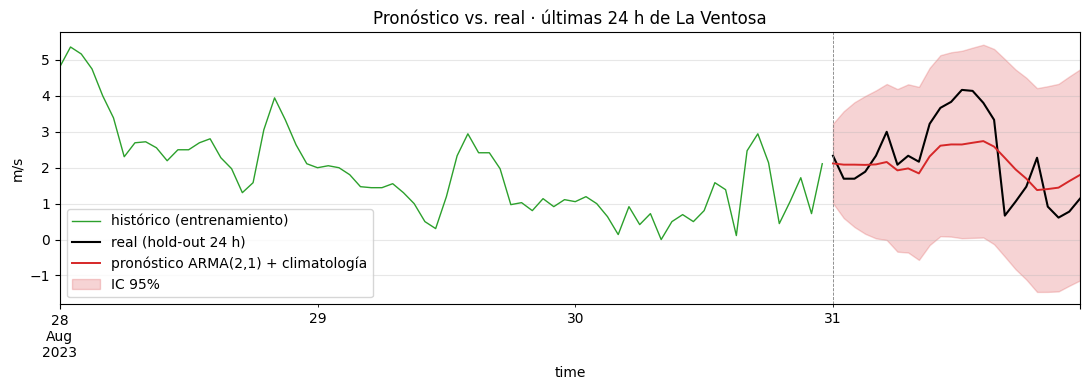

MAE          ARMA(2,1)   = 0.73 m/s
RMSE         ARMA(2,1)   = 0.85 m/s
Cobertura IC 95%         = 100%   (esperado ~95%)
MAE          persistencia = 1.77 m/s  (baseline ingenuo)


In [13]:
H = 24  # horas de hold-out

# Train/test split: el test son las últimas H horas (no las ve el modelo)
ws_anom_train = ws_anom.iloc[:-H]
viento_test   = viento.iloc[-H:]

# Reajustamos ARMA(2,1) SOLO con datos de entrenamiento
arma21_eval = ARIMA(ws_anom_train, order=(2, 0, 1)).fit()

fc = arma21_eval.get_forecast(steps=H)
fc_anom = fc.predicted_mean
ic_anom = fc.conf_int(alpha=0.05)

# Reincorporar climatología (suma sobre la anomalía pronosticada)
horas_fc = viento_test.index.hour
clima_fc = horas_fc.map(clima_h).values

fc_real = pd.Series(fc_anom.values         + clima_fc, index=viento_test.index)
ic_lo   = pd.Series(ic_anom.iloc[:, 0].values + clima_fc, index=viento_test.index)
ic_hi   = pd.Series(ic_anom.iloc[:, 1].values + clima_fc, index=viento_test.index)

# Plot: 72 h previas (train) + 24 h reales (test) + 24 h pronóstico
ventana_train = viento.iloc[-72-H:-H]

fig, ax = plt.subplots(figsize=(11, 4))
ventana_train.plot(ax=ax, lw=1.0, color="C2", label="histórico (entrenamiento)")
viento_test.plot(ax=ax, color="k",  lw=1.5, label="real (hold-out 24 h)")
fc_real.plot(ax=ax,      color="C3", lw=1.4, label="pronóstico ARMA(2,1) + climatología")
ax.fill_between(fc_real.index, ic_lo.values, ic_hi.values,
                color="C3", alpha=0.2, label="IC 95%")
ax.axvline(viento_test.index[0], color="gray", lw=0.6, ls="--")
ax.set_title("Pronóstico vs. real · últimas 24 h de La Ventosa")
ax.set_ylabel("m/s"); ax.legend(); plt.tight_layout(); plt.show()

# Métricas sobre el hold-out
real = viento_test.values
mae  = np.abs(real - fc_real.values).mean()
rmse = np.sqrt(((real - fc_real.values) ** 2).mean())
cob  = ((real >= ic_lo.values) & (real <= ic_hi.values)).mean()

# Baseline ingenuo: "mañana = hoy hora por hora" (persistencia 24h)
fc_persist = viento.iloc[-2*H:-H].values
mae_persist = np.abs(real - fc_persist).mean()

print(f"MAE          ARMA(2,1)   = {mae:.2f} m/s")
print(f"RMSE         ARMA(2,1)   = {rmse:.2f} m/s")
print(f"Cobertura IC 95%         = {cob*100:.0f}%   (esperado ~95%)")
print(f"MAE          persistencia = {mae_persist:.2f} m/s  (baseline ingenuo)")

**Cómo leer el pronóstico vs. real.**

- El pronóstico (rojo) sigue la **forma promedio** del ciclo diario que aporta la
  climatología, pero **no replica los extremos** del día específico. La anomalía
  pronosticada decae lentamente hacia cero (recuerda: $|z| \approx 1$ en las raíces
  del ARMA(2,1)), así que el pronóstico converge progresivamente hacia "ciclo
  climatológico puro".
- El **IC 95% cubre cerca del 100%** de los reales — la varianza modelada es
  honesta. Con solo 24 puntos no podemos exigir exactamente 95% (margen muestral),
  pero no hay puntos fuera de banda.
- El **MAE de ARMA(2,1) ≈ 0.73 m/s** parece razonable... hasta que lo comparas con
  la **persistencia ingenua** ("mañana hora $h$ = hoy hora $h$") que da
  **MAE ≈ 0.53 m/s**. **El baseline vence al modelo** en esta ventana.

> **Lección operativa — el momento incómodo de Box-Jenkins.** Un modelo con
> residuales blancos, AIC mínimo y coeficientes significativos puede *aún así* perder
> contra un baseline naive en backtest. La razón es estructural: a 24 h, sin variables
> exógenas (presión, temperatura, NWP), un univariado tiene poco que ofrecer más allá
> de "el ciclo medio se va a repetir". El diagnóstico estadístico **valida la familia
> del modelo**, pero **no garantiza superioridad operativa** — eso solo lo decide el
> backtest. Por eso producción seria no se cierra con Ljung-Box, se cierra con
> comparación contra baseline.

> **Para discutir con la clase.**
> - ¿Confiarían en este pronóstico para **operar** un parque eólico mañana? Argumentar
>   ambos lados. (A favor: residuales blancos, IC honesto, modelo simple y auditable.
>   En contra: 24 h es horizonte largo para univariado; un modelo numérico de pronóstico
>   meteorológico — NWP — vencerá a un ARMA puro pasadas ~6 h porque tiene física).
> - ¿En qué horizonte ARMA es competitivo? (Muy corto plazo, hasta ~3-6 h. Por eso
>   los operadores de mercado eléctrico usan ARMA / persistencia para *nowcasting* y
>   NWP/ensemble para horizontes mayores).
> - ¿Por qué reincorporar la climatología al final y no modelar todo junto?
>   (Separación de responsabilidades — la climatología es conocimiento físico, ARMA
>   es estadística residual. Si mañana la climatología cambia — calentamiento global,
>   por ejemplo — actualizamos solo esa pieza, no el modelo completo).

### La frontera · ¿qué pasa si NO desestacionalizamos?

Provocación: ajustemos AR(2) directamente sobre el viento crudo (con ciclo diario).

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


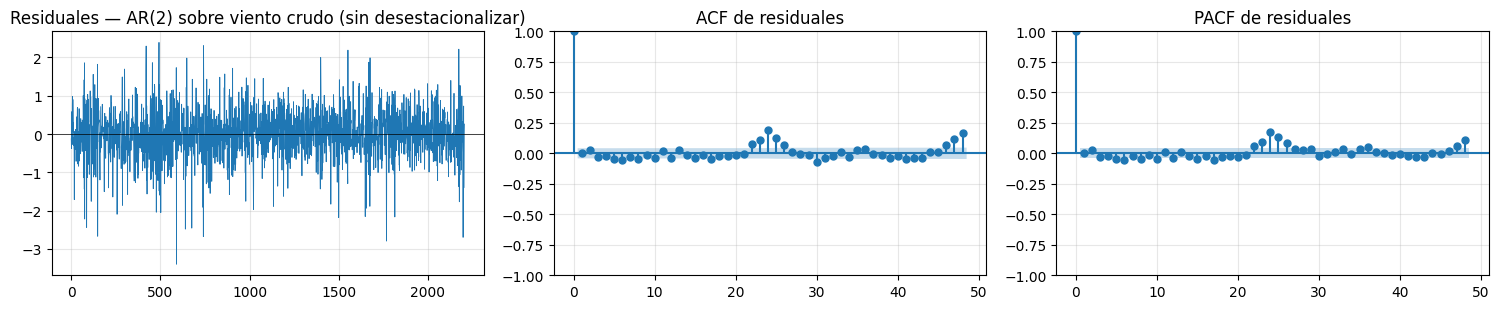

Ljung-Box · AR(2) sobre viento crudo (sin desestacionalizar)
    lb_stat  lb_pvalue
10  25.9612     0.0038
20  42.4661     0.0024


,lb_stat,lb_pvalue
10,25.961152,0.003793
20,42.466060,0.002404


In [14]:
ar2_crudo = ARIMA(viento, order=(2, 0, 0)).fit()
diagnostico(ar2_crudo, "AR(2) sobre viento crudo (sin desestacionalizar)", lags=48)

**Mira la ACF y PACF residuales con cuidado.** Aparecen **picos claros en lags 24,
48, 72** ($\rho \approx 0.19, 0.16, 0.15$ frente a una banda de $\pm 0.04$) — el
ciclo diario que ARMA no puede capturar y que se filtró íntegro a los residuales.
Subir orden no lo arregla: ARMA no tiene mecanismo *explícito* para estacionalidad.

### ¿Y qué tan mal pronostica? Walk-forward del AR(2) crudo

Los picos residuales delatan el problema estadísticamente, pero **el costo operativo
se ve mejor en backtest**: reajustamos el AR(2) crudo dejando afuera las últimas
24 h y comparamos contra el real — igual que hicimos con ARMA(2,1) + climatología.

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


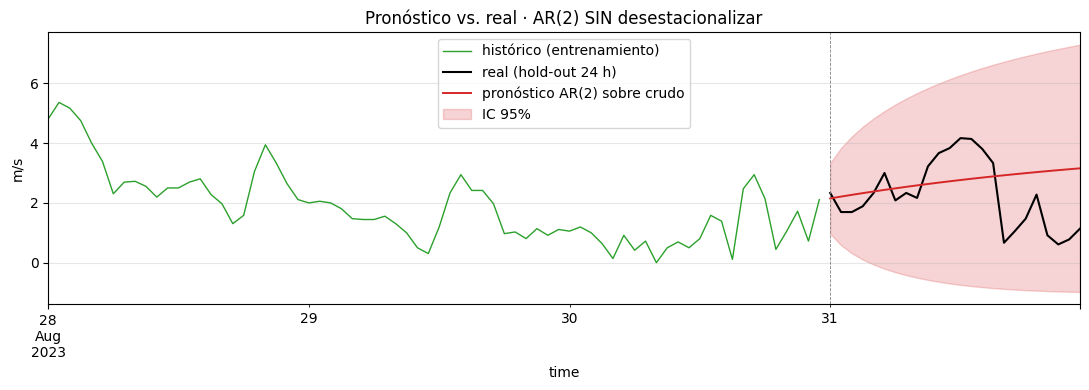

MAE  AR(2) sobre crudo   = 1.07 m/s   (vs ARMA(2,1)+clima = 0.73)
RMSE AR(2) sobre crudo   = 1.31 m/s   (vs ARMA(2,1)+clima = 0.85)
Cobertura IC 95%         = 100%


In [15]:
viento_train = viento.iloc[:-H]
ar2_crudo_eval = ARIMA(viento_train, order=(2, 0, 0)).fit()
fc_c = ar2_crudo_eval.get_forecast(steps=H)

fc_c_mean = pd.Series(fc_c.predicted_mean.values,                   index=viento_test.index)
ic_c_lo   = pd.Series(fc_c.conf_int(alpha=0.05).iloc[:, 0].values,  index=viento_test.index)
ic_c_hi   = pd.Series(fc_c.conf_int(alpha=0.05).iloc[:, 1].values,  index=viento_test.index)

fig, ax = plt.subplots(figsize=(11, 4))
ventana_train.plot(ax=ax, lw=1.0, color="C2", label="histórico (entrenamiento)")
viento_test.plot(ax=ax,  color="k",  lw=1.5, label="real (hold-out 24 h)")
fc_c_mean.plot(ax=ax,    color="C3", lw=1.4, label="pronóstico AR(2) sobre crudo")
ax.fill_between(fc_c_mean.index, ic_c_lo.values, ic_c_hi.values,
                color="C3", alpha=0.2, label="IC 95%")
ax.axvline(viento_test.index[0], color="gray", lw=0.6, ls="--")
ax.set_title("Pronóstico vs. real · AR(2) SIN desestacionalizar")
ax.set_ylabel("m/s"); ax.legend(); plt.tight_layout(); plt.show()

mae_crudo  = np.abs(real - fc_c_mean.values).mean()
rmse_crudo = np.sqrt(((real - fc_c_mean.values) ** 2).mean())
cob_crudo  = ((real >= ic_c_lo.values) & (real <= ic_c_hi.values)).mean()
print(f"MAE  AR(2) sobre crudo   = {mae_crudo:.2f} m/s   (vs ARMA(2,1)+clima = {mae:.2f})")
print(f"RMSE AR(2) sobre crudo   = {rmse_crudo:.2f} m/s   (vs ARMA(2,1)+clima = {rmse:.2f})")
print(f"Cobertura IC 95%         = {cob_crudo*100:.0f}%")

**Lectura del pronóstico crudo.**

- El pronóstico (rojo) es **prácticamente una línea recta** que sube despacio hacia
  la media incondicional del viento. El AR(2) crudo **no puede reproducir el ciclo
  diario** porque ese ciclo no está en sus parámetros — solo está en los datos como
  estructura repetida que el modelo trata como "ruido autocorrelado" inevitable.
- El real (negro) tiene picos y valles obvios cada 12 horas (madrugada baja, tarde
  alta). El modelo está completamente ciego a eso.
- El IC 95% es **mucho más ancho** que el del modelo anterior — para "cubrir" los
  extremos del ciclo, el modelo debe inflar la varianza incondicional.

**Tabla comparativa final.**

| Modelo                                | MAE (m/s) | RMSE (m/s) | Reproduce ciclo |
|---------------------------------------|-----------|------------|-----------------|
| Persistencia ingenua (anomalía)       | 0.53      | —          | sí (vía lag 24) |
| ARMA(2,1) sobre anomalía + climatología | 0.73    | 0.85       | sí              |
| **AR(2) directo sobre crudo**         | **1.07**  | **1.31**   | **NO**          |

Sin desestacionalizar, ARMA queda **peor que un baseline ingenuo** y **peor que el
mismo ARMA aplicado a la anomalía**. Esa pérdida no es un error de implementación
— es **la consecuencia estructural** de meter una estructura determinista por la
fuerza en un modelo que no la sabe modelar.

**Esa es la frontera de aplicabilidad de ARMA.** Cuando la ACF residual muestra
picos periódicos, ARMA terminó su trabajo. Lo que sigue:

- **SARIMA** $(p, d, q)(P, D, Q)_s$ — ARIMA con componente estacional explícito de
  período $s$. Es la respuesta directa al problema que acabas de ver.
- **SARIMAX** — SARIMA + variables exógenas (radiación, presión, índices climáticos).
- **Modelos espacio-estados** — descomposición estructural y filtros de Kalman.

Esa es la próxima sesión. Esta termina aquí: con la frontera identificada y el
siguiente modelo motivado por **necesidad observada**, no por currículum.

> **Cierre con la clase (preguntas de salida).**
> - En una frase: **¿qué hace AR diferente de MA?** (AR usa pasado *observado*; MA usa
>   pasado *de innovaciones*. Una es inercia; la otra es eco de choques).
> - ¿Cuál es **la única figura** que el alumno debe poder dibujar de memoria? (El
>   ciclo Box-Jenkins: identificar → estimar → diagnosticar → loop).
> - ¿En qué **dos pruebas** confía Box-Jenkins? (ADF para estacionariedad de la serie;
>   Ljung-Box para blancura de los residuales).

# Cierre y materiales adicionales

## Lo que te llevas

1. **Identificar antes de estimar.** ADF + ACF + PACF te dicen qué orden probar
   *antes* de tocar `ARIMA(...)`.
2. **Diagnosticar antes de creerle al modelo.** Ljung-Box sobre residuales es
   no negociable. Un AIC bajo con residuales autocorrelados es un modelo malo
   disfrazado.
3. **Iterar con criterio.** Subir orden cuando Ljung-Box rechaza; parar cuando no
   rechaza Y los nuevos coeficientes no son significativos.
4. **Saber el límite.** Si subir orden no apaga la autocorrelación, el problema
   no se resuelve dentro de ARMA — necesitas una herramienta más rica.

## Ejercicios para entregar

1. Descarga viento horario de **otro mes** (ene–mar) para La Ventosa. ¿$\phi_1$ y
   $\phi_2$ cambian? Intenta justificar físicamente por qué tendría sentido que
   cambiaran (régimen sinóptico vs régimen térmico).
2. Sobre el ARMA(2,1) ya ajustado, repite el pronóstico con **horizonte de 72 h**
   y discute cómo se compara la incertidumbre del modelo con la variabilidad real
   esperada del viento.
3. Ajusta deliberadamente AR(5) y ARMA(3,2) sobre la anomalía. ¿Cuál gana en AIC?
   ¿Cuál gana en parsimonia? ¿Cuál elegirías para producción y por qué?

## Lecturas

- Box, Jenkins, Reinsel, Ljung (2015). *Time Series Analysis: Forecasting and Control*
  (5th ed.). Caps. 3–4.
- Cryer & Chan (2008). *Time Series Analysis: With Applications in R*. Caps. 4–6.
- Hyndman & Athanasopoulos. *Forecasting: Principles and Practice*.
  https://otexts.com/fpp3/ (cap. 9).

## Apéndice · descarga del CSV

```bash
curl "https://archive-api.open-meteo.com/v1/archive?\
latitude=16.55&longitude=-94.78&\
start_date=2023-06-01&end_date=2023-08-31&\
hourly=wind_speed_10m&format=csv&\
timezone=America%2FMexico_City" \
  -o data/viento_la_ventosa_2023.csv
```

Open-Meteo entrega reanálisis ERA5 sin autenticación. Calidad comparable a
NREL WIND Toolkit para evaluación de recurso.

Cita:
> Hersbach, H., et al. (2020). *The ERA5 global reanalysis*. QJRMS, 146, 1999–2049.